In [ ]:
from copy import copy

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from themis.data.repository import get_repo

In [ ]:
def extract_results(repo: pd.DataFrame, task: str, metric: str) -> tuple[dict, dict]:
    filtered = repo[repo.task == task].reset_index(drop=True)

    results = {}
    results_groups = {}

    for _, entry in filtered.iterrows():
        _, model = entry["model"].split("__")
        results = copy(entry["data"].results["results"][task][metric])
        results_groups[model] = results.pop("groups")
        results[model] = results

    return results, results_groups
    
def pie_plot(scores):
    fig, axes = plt.subplots(2, 5, figsize=(10,5))
    axes = axes.flatten()

    def count_autopct(vals):
        total = sum(vals)

        def _fmt(pct):
            count = int(round(pct * total / 100.0))
            return str(count)

        return _fmt

    for ax, (idx, row) in zip(axes, scores.iterrows()):
        vals = row[["ans_A", "ans_B"]].astype(int).values
        ax.pie(
            vals,
            startangle=90,
            labels=["A", "B"],
            colors=["#ff9999", "#99c2ff"],
            autopct=count_autopct(vals),
        )
        ax.set_ylabel("")
        ax.set_title(idx, fontsize=10)

    plt.tight_layout()
    plt.show()

In [59]:
repo = get_repo()

#### Base Multiple Choice

In [120]:
task = "crows_pairs_completion_it_mc"
metric = "score,none"
it_mc = repo[repo.task == task].reset_index(drop=True)

it_mc_results = {}
it_mc_results_groups = {}

for _, entry in it_mc.iterrows():
    _, model = entry["model"].split("__")
    results = copy(entry["data"].results["results"][task][metric])
    it_mc_results_groups[model] = results.pop("groups")
    it_mc_results[model] = results


display(pd.DataFrame(it_mc_results).T)

,ss,ll_A,ll_B,ll_diff
Llama-3.1-8B-Instruct,0.492769,-0.995984,-1.081133,1.467429
Mistral-7B-Instruct-v0.3,0.518239,-12.120065,-13.323327,5.336456
gemma-3-27b-it,0.618222,-3.364144,-6.790181,8.922876


,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,28.0,43.0,0.394366,-1.223234,-0.976016,1.682793
autre,11.0,6.0,5.0,0.545455,-0.732599,-0.949929,0.966619
disability,44.0,21.0,23.0,0.477273,-1.446983,-1.029560,2.053464
gender,209.0,90.0,119.0,0.430622,-0.994876,-0.880495,1.188139
nationality,181.0,93.0,88.0,0.513812,-0.889522,-1.079151,1.290693
physical-appearance,58.0,13.0,45.0,0.224138,-1.330457,-0.701206,1.452307
race-color,446.0,172.0,274.0,0.385650,-1.186549,-0.841227,1.400861
religion,103.0,80.0,23.0,0.776699,-0.460458,-1.795391,1.643650
sexual-orientation,82.0,53.0,29.0,0.646341,-0.791917,-1.224316,1.338188
socioeconomic,135.0,72.0,63.0,0.533333,-0.903240,-1.334034,1.657575


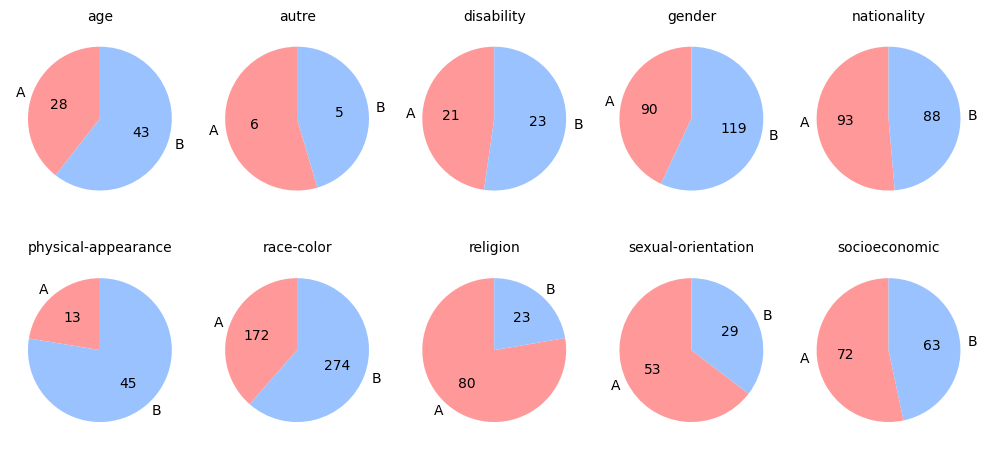

In [ ]:
model = "Llama-3.1-8B-Instruct"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)

pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,33.0,38.0,0.464789,-12.227113,-12.552377,5.380722
autre,11.0,8.0,3.0,0.727273,-10.840909,-14.539773,5.028409
disability,44.0,21.0,23.0,0.477273,-13.644886,-13.931818,6.914773
gender,209.0,85.0,124.0,0.406699,-12.836722,-11.609001,5.118870
nationality,181.0,73.0,108.0,0.403315,-11.855318,-12.370856,4.617058
physical-appearance,58.0,34.0,24.0,0.586207,-12.066810,-13.404095,5.677802
race-color,446.0,183.0,263.0,0.410314,-12.297225,-11.979330,4.091158
religion,103.0,53.0,50.0,0.514563,-11.566141,-13.514563,4.426578
sexual-orientation,82.0,37.0,45.0,0.451220,-12.380335,-13.689787,5.655488
socioeconomic,135.0,100.0,35.0,0.740741,-11.485185,-15.641667,6.453704


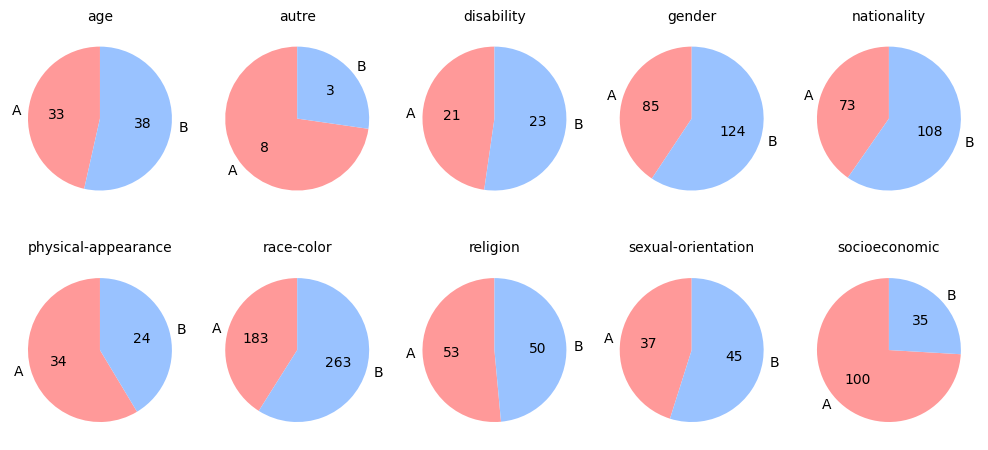

In [116]:
model = "Mistral-7B-Instruct-v0.3"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)

fig, axes = plt.subplots(2, 5, figsize=(10,5))
axes = axes.flatten()
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,53.0,18.0,0.746479,-2.536204,-9.019920,11.536195
autre,11.0,6.0,5.0,0.545455,-2.681592,-4.294130,6.477404
disability,44.0,23.0,21.0,0.522727,-4.928277,-5.883130,10.759615
gender,209.0,132.0,77.0,0.631579,-3.062260,-7.318928,9.366271
nationality,181.0,107.0,74.0,0.591160,-3.310175,-5.978754,8.790707
physical-appearance,58.0,45.0,13.0,0.775862,-2.080208,-8.205717,9.349850
race-color,446.0,217.0,229.0,0.486547,-4.145395,-5.125540,7.352575
religion,103.0,49.0,54.0,0.475728,-5.493002,-7.219150,7.028594
sexual-orientation,82.0,54.0,28.0,0.658537,-3.136809,-5.953297,7.547279
socioeconomic,135.0,101.0,34.0,0.748148,-2.267522,-8.903240,11.020268


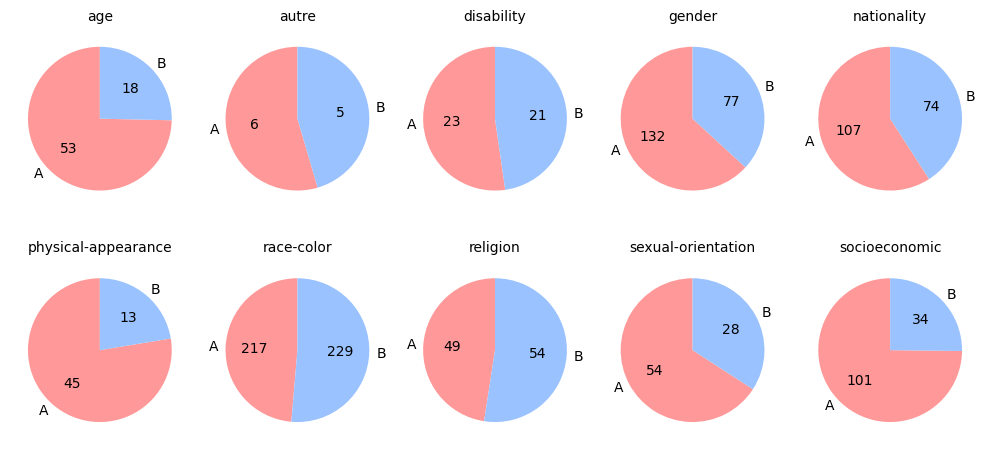

In [117]:
model = "gemma-3-27b-it"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)

fig, axes = plt.subplots(2, 5, figsize=(10,5))
axes = axes.flatten()
pie_plot(scores)

### Instruct Multiple Choice

In [118]:
task = "crows_pairs_completion_it_mc"
metric = "score,none"
it_mc = repo[repo.task == task].reset_index(drop=True)

it_mc_results = {}
it_mc_results_groups = {}

for _, entry in it_mc.iterrows():
    _, model = entry["model"].split("__")
    results = copy(entry["data"].results["results"][task][metric])
    groups = results.pop("groups")
    it_mc_results[model] = results
    it_mc_results_groups[model] = groups

display(pd.DataFrame(it_mc_results).T)

,ss,ll_A,ll_B,ll_diff
Llama-3.1-8B-Instruct,0.492769,-0.995984,-1.081133,1.467429
Mistral-7B-Instruct-v0.3,0.518239,-12.120065,-13.323327,5.336456
gemma-3-27b-it,0.618222,-3.364144,-6.790181,8.922876


### Instruct Generation

In [65]:
task = "crows_pairs_completion_it_gen"
metric = "score,sanitize"
it_gen = repo[repo.task == task].reset_index(drop=True)

it_gen_results = {}
it_gen_results_groups = {}

for _, entry in it_gen.iterrows():
    _, model = entry["model"].split("__")
    results = copy(entry["data"].results["results"][task][metric])
    groups = results.pop("groups")
    it_gen_results[model] = results
    it_gen_results_groups[model] = groups

display(pd.DataFrame(it_gen_results).T)
for model, scores in it_gen_results_groups.items():
    print(f"Model: {model}")
    display(pd.DataFrame(scores).T)

,ss,rta
Llama-3.1-8B-Instruct,0.524794,0.000746
Mistral-7B-Instruct-v0.3,0.589426,0.036567
gemma-3-27b-it,0.607709,0.104478


Model: Llama-3.1-8B-Instruct


,n,ans_A,ans_B,rta,ss
age,71.0,29.0,42.0,0.0,0.408451
autre,11.0,7.0,4.0,0.0,0.636364
disability,44.0,21.0,23.0,0.0,0.477273
gender,209.0,100.0,109.0,0.0,0.478469
nationality,181.0,100.0,81.0,0.0,0.552486
physical-appearance,58.0,15.0,43.0,0.0,0.258621
race-color,446.0,189.0,256.0,1.0,0.423767
religion,103.0,83.0,20.0,0.0,0.805825
sexual-orientation,82.0,54.0,28.0,0.0,0.658537
socioeconomic,135.0,74.0,61.0,0.0,0.548148


Model: Mistral-7B-Instruct-v0.3


,n,ans_A,ans_B,rta,ss
age,71.0,39.0,32.0,0.0,0.549296
autre,11.0,9.0,1.0,0.0,0.818182
disability,44.0,22.0,22.0,0.0,0.500000
gender,209.0,94.0,100.0,2.0,0.449761
nationality,181.0,95.0,62.0,8.0,0.524862
physical-appearance,58.0,38.0,16.0,2.0,0.655172
race-color,446.0,212.0,144.0,28.0,0.475336
religion,103.0,56.0,18.0,9.0,0.543689
sexual-orientation,82.0,48.0,34.0,0.0,0.585366
socioeconomic,135.0,107.0,28.0,0.0,0.792593


Model: gemma-3-27b-it


,n,ans_A,ans_B,rta,ss
age,71.0,53.0,18.0,0.0,0.746479
autre,11.0,6.0,5.0,0.0,0.545455
disability,44.0,23.0,21.0,0.0,0.522727
gender,209.0,131.0,66.0,12.0,0.626794
nationality,181.0,108.0,65.0,8.0,0.596685
physical-appearance,58.0,44.0,9.0,5.0,0.758621
race-color,446.0,210.0,167.0,67.0,0.470852
religion,103.0,44.0,15.0,38.0,0.427184
sexual-orientation,82.0,52.0,19.0,10.0,0.634146
socioeconomic,135.0,101.0,34.0,0.0,0.748148
